# Sesión 3 — Análisis momento–curvatura y rótulas plásticas

## Aplicación: edificio didáctico de 2 pisos

Este notebook desarrolla la **Sesión 3 del curso** usando directamente los módulos y el archivo JSON de `PUSHOVER_PORTABLE`. El resultado principal es una biblioteca de leyes $M$–$\theta(P)$ para las secciones `C1`, `C2`, `V1` y `V2`, lista para ser consumida por las sesiones 4, 5 y 6.

> **Alcance académico.** Se estudia la respuesta seccional a flexocompresión y su idealización mediante rótulas plásticas concentradas. Esto no constituye por sí solo la evaluación completa de una estructura real; aún deben comprobarse cortante, anclajes, empalmes, interacción axial–flexión y criterios normativos de aceptación.

## 1. Resultados de aprendizaje

Al terminar esta sesión, el estudiante podrá:

1. Explicar la compatibilidad de deformaciones y el equilibrio axial de una sección discretizada en fibras.
2. Construir e interpretar una curva momento–curvatura.
3. Reconocer la influencia de la carga axial sobre resistencia, rigidez y ductilidad.
4. Transformar $M$–$\phi$ en una ley local $M$–$\theta$ usando una longitud de rótula plástica $L_p$.
5. Generar y verificar el contrato computacional de la sesión 3.

## 2. Preparación del entorno y trazabilidad

La celda siguiente busca la raíz del curso sin rutas absolutas, coloca `PUSHOVER_PORTABLE` al inicio de `sys.path` y muestra el origen real de los módulos importados. Así evitamos depender de copias externas del código.

In [1]:
from pathlib import Path
from copy import deepcopy
import json
import sys

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=5, suppress=True)

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta / "temario.md").is_file() and (carpeta / "PUSHOVER_PORTABLE").is_dir():
            return carpeta
    raise FileNotFoundError("No se encontró la raíz del curso ni PUSHOVER_PORTABLE/.")

RAIZ_CURSO = buscar_raiz()
RAIZ_PORTABLE = RAIZ_CURSO / "PUSHOVER_PORTABLE"
if str(RAIZ_PORTABLE) in sys.path:
    sys.path.remove(str(RAIZ_PORTABLE))
sys.path.insert(0, str(RAIZ_PORTABLE))

from sesion_02.mander_concreto import modulo_elasticidad
from sesion_03 import modelo_seccion
from sesion_03.casos_medrano import preparar_seccion
from sesion_03.modelo_seccion import (
    crear_fibras, respuesta_seccion, resolver_eps0,
    curva_momento_curvatura, resumir_curva, utilizacion_limite,
)
from sesion_03.modelo_rotula import propiedades_rotula
from sesion_03.biblioteca_rotulas import (
    generar_biblioteca_desde_entrada, guardar_contrato_sesion03,
)

RUTA_JSON = RAIZ_PORTABLE / "sesion_03" / "datos" / "entrada_secciones_2pisos.json"
RUTA_SALIDA = RAIZ_CURSO / "sesion_03" / "resultados_portable_2pisos"

print("Raíz del curso :", RAIZ_CURSO)
print("Sistema portable:", RAIZ_PORTABLE)
print("Datos de entrada :", RUTA_JSON.relative_to(RAIZ_CURSO))
print("Módulo cargado   :", Path(modelo_seccion.__file__).relative_to(RAIZ_CURSO))
assert RAIZ_PORTABLE in Path(modelo_seccion.__file__).resolve().parents


Raíz del curso : D:\DOCENCIA\PRINBEL\PUSHOVER PORTICOS
Sistema portable: D:\DOCENCIA\PRINBEL\PUSHOVER PORTICOS\PUSHOVER_PORTABLE
Datos de entrada : PUSHOVER_PORTABLE\sesion_03\datos\entrada_secciones_2pisos.json
Módulo cargado   : PUSHOVER_PORTABLE\sesion_03\modelo_seccion.py


## 3. Lectura del edificio y de sus secciones

El JSON usa el sistema de unidades **kgf–cm–rad**. El edificio tiene dos pisos, un vano de 6 m y dos pórticos resistentes coplanares en la dirección analizada. En esta sesión solo se estudian sus secciones; la geometría estructural completa se ensamblará en la sesión 5.

In [2]:
entrada = json.loads(RUTA_JSON.read_text(encoding="utf-8"))
edificio = entrada["edificio"]
secciones_json = entrada["secciones"]

print(f"Edificio: {edificio['n_pisos']} pisos, {edificio['n_vanos_por_portico']} vano por pórtico")
print(f"Luz = {edificio['luz_cm']/100:.2f} m; altura de entrepiso = {edificio['altura_entrepiso_cm']/100:.2f} m")
print(f"Pórticos analizados: {', '.join(edificio['porticos_direccion_analisis'])}")
print("\nSecciones declaradas:")
print("{:<4} {:<9} {:<13} {:>7} {:>8} {:>7}".format("ID", "Tipo", "b×h (cm)", "f'c", "fy", "Lp"))
for sid, sec in secciones_json.items():
    dimensiones = f"{sec['b_cm']:.0f}×{sec['h_cm']:.0f}"
    print(f"{sid:<4} {sec['tipo']:<9} {dimensiones:<13} {sec['fc_kgf_cm2']:7.1f} {sec['fy_kgf_cm2']:8.1f} {sec['Lp_cm']:7.1f}")

assert set(secciones_json) == {"C1", "C2", "V1", "V2"}
assert entrada["unidades"]["longitud"] == "cm"


Edificio: 2 pisos, 1 vano por pórtico
Luz = 6.00 m; altura de entrepiso = 3.00 m
Pórticos analizados: P1, P2

Secciones declaradas:
ID   Tipo      b×h (cm)          f'c       fy      Lp
C1   columna   60×60           210.0   4200.0    30.0
C2   columna   55×55           210.0   4200.0    27.5
V1   viga      40×55           210.0   4200.0    27.5
V2   viga      30×40           210.0   4200.0    20.0


## 4. Mecánica de la sección discretizada en fibras

Se adopta la hipótesis de que las secciones planas permanecen planas. Para una curvatura prescrita $\phi$, la deformación longitudinal de una fibra situada en $y_i$ es

$$\varepsilon_i=\varepsilon_0+\phi y_i,$$

donde $\varepsilon_0$ es la deformación axial del eje de referencia. Cada deformación se transforma en esfuerzo mediante la ley constitutiva correspondiente: concreto confinado, concreto no confinado o acero.

El valor de $\varepsilon_0$ no se conoce de antemano. El programa lo obtiene por bisección hasta satisfacer el equilibrio axial

$$R_N(\varepsilon_0)=\sum_i \sigma_i(\varepsilon_i)A_i-P=0.$$

Una vez equilibrada la fuerza axial, el momento resistente se calcula como

$$M=\sum_i \sigma_i A_i y_i.$$

Convención del módulo: la compresión y la carga axial $P$ son positivas; $M$ se reporta en kgf·cm y $\phi$ en cm$^{-1}$.

### 4.1 Preparación y confinamiento de la columna C1

`preparar_seccion` convierte pulgadas a centímetros, ubica las barras, calcula el núcleo medido al eje del estribo y obtiene los parámetros de confinamiento requeridos por el modelo de Mander.

In [3]:
cfg_c1 = preparar_seccion("C1", RUTA_JSON)
d = cfg_c1["datos_seccion"]

print(f"Sección C1             : {d['b']:.1f} × {d['h']:.1f} cm")
print(f"Área bruta Ag          : {d['Ag']:.1f} cm²")
print(f"Acero longitudinal As  : {d['As_total']:.2f} cm² ({100*d['rho_l']:.3f} %)")
print(f"Núcleo bc × hc         : {d['bc']:.2f} × {d['hc']:.2f} cm")
print(f"Efectividad ke         : {cfg_c1['ke']:.4f}")
print(f"Presión lateral efectiva: {cfg_c1['fl_ef']:.3f} kgf/cm²")
print(f"Resistencia confinada  : {cfg_c1['fcc']:.2f} kgf/cm²")
print(f"Deformación última εcu : {cfg_c1['eps_cu']:.5f}")
print(f"Longitud adoptada Lp   : {cfg_c1['Lp_cm']:.1f} cm")

assert np.isclose(d["Ag"], d["b"] * d["h"])
assert cfg_c1["fl_ef"] > 0 and cfg_c1["eps_cu"] > d["epsco"]


Sección C1             : 60.0 × 60.0 cm
Área bruta Ag          : 3600.0 cm²
Acero longitudinal As  : 37.70 cm² (1.047 %)
Núcleo bc × hc         : 51.05 × 51.05 cm
Efectividad ke         : 0.7155
Presión lateral efectiva: 8.389 kgf/cm²
Resistencia confinada  : 263.13 kgf/cm²
Deformación última εcu : 0.01648
Longitud adoptada Lp   : 30.0 cm


### 4.2 Discretización y comprobación de áreas

El concreto se integra mediante franjas horizontales. Las barras son fibras discretas y su área se descuenta del concreto confinado para evitar contabilizarla dos veces.

Concreto no confinado :   994.153 cm²
Concreto confinado     :  2568.148 cm²
Acero longitudinal     :    37.699 cm²
Área integrada         :  3600.000 cm²
Error respecto a Ag    : -4.547e-13 cm²


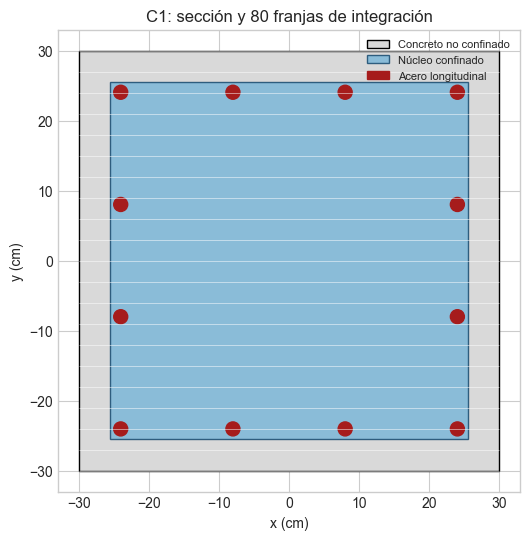

In [4]:
fibras = crear_fibras(d)
A_no = fibras["A_no"].sum()
A_conf = fibras["A_conf"].sum()
A_acero = fibras["As"].sum()
A_integrada = A_no + A_conf + A_acero

print(f"Concreto no confinado : {A_no:9.3f} cm²")
print(f"Concreto confinado     : {A_conf:9.3f} cm²")
print(f"Acero longitudinal     : {A_acero:9.3f} cm²")
print(f"Área integrada         : {A_integrada:9.3f} cm²")
print(f"Error respecto a Ag    : {A_integrada-d['Ag']:+.3e} cm²")
assert np.isclose(A_integrada, d["Ag"], rtol=0, atol=1e-8)

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(plt.Rectangle((-d['b']/2, -d['h']/2), d['b'], d['h'],
                           facecolor="#d9d9d9", edgecolor="black", label="Concreto no confinado"))
ax.add_patch(plt.Rectangle((-d['bc']/2, -d['hc']/2), d['bc'], d['hc'],
                           facecolor="#7db7d8", edgecolor="#174a6e", alpha=0.85,
                           label="Núcleo confinado"))
for i, barra in enumerate(d["barras"]):
    ax.add_patch(plt.Circle((barra['x_cm'], barra['y_cm']), barra['diametro_cm']/2,
                            color="#a61c1c", label="Acero longitudinal" if i == 0 else None))
salto = max(1, d["n_fibras_y"] // 20)
ax.hlines(fibras["bordes"][::salto], -d['b']/2, d['b']/2, color="white", lw=0.5, alpha=0.7)
ax.set(xlabel="x (cm)", ylabel="y (cm)", title=f"C1: sección y {d['n_fibras_y']} franjas de integración")
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8)
plt.show()


### 4.3 Equilibrio axial para un estado de curvatura

Como demostración, se prescribe $\nu=P/(A_gf'_c)=0.10$ y una curvatura de $5\times10^{-5}$ cm$^{-1}$. El residuo debe ser pequeño frente a la escala resistente $A_gf'_c$.

In [5]:
nu = 0.10
P = nu * d["Ag"] * d["fco"]
phi_prueba = 5.0e-5
estado = resolver_eps0(phi_prueba, P, fibras, d, cfg_c1["fl_ef"], cfg_c1["rho_s"])
residuo = estado["N"] - P

print(f"P objetivo            : {P:,.2f} kgf")
print(f"N interno equilibrado : {estado['N']:,.2f} kgf")
print(f"Residuo N-P           : {residuo:+.4f} kgf")
print(f"Deformación axial ε0  : {estado['eps0']:+.6e}")
print(f"Momento resistente    : {abs(estado['M'])/1e5:.3f} tf·m")
assert abs(residuo) <= 1e-5 * max(P, d["Ag"] * d["fco"])


P objetivo            : 75,600.00 kgf
N interno equilibrado : 75,599.21 kgf
Residuo N-P           : -0.7894 kgf
Deformación axial ε0  : -4.811859e-04
Momento resistente    : 42.137 tf·m


## 5. Curva momento–curvatura de C1

El algoritmo incrementa $\phi$, equilibra $N=P$ en cada punto y se detiene cuando el concreto confinado alcanza $\varepsilon_{cu}$ o el acero alcanza $\varepsilon_{su}$. La fluencia se identifica con $|\varepsilon_s|\ge f_y/E_s$.

La rigidez secante usada posteriormente es

$$EI_{sec}=\frac{M_y}{\phi_y}.$$

P/(Ag f'c) = 0.10
Fluencia: φy = 0.00672 1/m; My = 48.390 tf·m
Máximo : φu = 0.03025 1/m; Mu = 57.064 tf·m
EI secante = 7.1979e+10 kgf·cm²
Evento final = concreto (33 estados equilibrados)


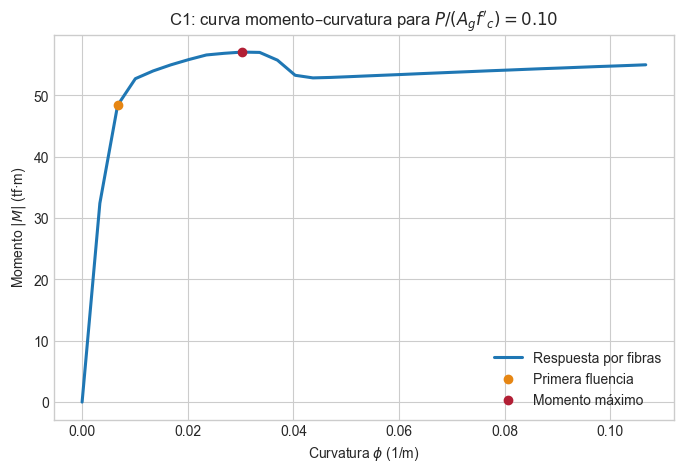

In [6]:
registros = curva_momento_curvatura(
    P, fibras, d, cfg_c1["fl_ef"], cfg_c1["rho_s"], cfg_c1["eps_cu"],
    phi_max=entrada["biblioteca_rotulas"]["phi_max_1_cm"],
    n_pasos=entrada["biblioteca_rotulas"]["n_pasos"],
)
resumen = resumir_curva(registros, P)
phi = np.array([r["phi"] for r in registros])
M = np.abs([r["M"] for r in registros])

print(f"P/(Ag f'c) = {nu:.2f}")
print(f"Fluencia: φy = {resumen['phi_y_1_cm']*100:.5f} 1/m; My = {resumen['My_kgf_cm']/1e5:.3f} tf·m")
print(f"Máximo : φu = {resumen['phi_u_1_cm']*100:.5f} 1/m; Mu = {resumen['Mu_kgf_cm']/1e5:.3f} tf·m")
print(f"EI secante = {resumen['EI_sec_kgf_cm2']:.4e} kgf·cm²")
print(f"Evento final = {resumen['evento_final']} ({len(registros)} estados equilibrados)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(phi*100, M/1e5, lw=2.2, label="Respuesta por fibras")
ax.scatter(resumen['phi_y_1_cm']*100, resumen['My_kgf_cm']/1e5, color="#e68613", zorder=3, label="Primera fluencia")
ax.scatter(resumen['phi_u_1_cm']*100, resumen['Mu_kgf_cm']/1e5, color="#b21f35", zorder=3, label="Momento máximo")
ax.set(xlabel=r"Curvatura $\phi$ (1/m)", ylabel=r"Momento $|M|$ (tf·m)",
       title=r"C1: curva momento–curvatura para $P/(A_g f'_c)=0.10$")
ax.legend()
plt.show()


### 5.1 Verificación independiente de rigidez

Se compara $EI_{sec}$ con la rigidez bruta $E_cI_g$. La comparación es solo una comprobación de orden de magnitud: la sección fisurada, el acero y la carga axial hacen que ambas rigideces no coincidan necesariamente.

In [7]:
Ec = modulo_elasticidad(d["fco"])
Ig = d["b"] * d["h"]**3 / 12
EI_bruto = Ec * Ig
razon_rigidez = resumen["EI_sec_kgf_cm2"] / EI_bruto
print(f"Ec = {Ec:,.1f} kgf/cm²")
print(f"Ig = {Ig:,.1f} cm⁴")
print(f"EIsec/EcIg = {razon_rigidez:.3f}")
assert np.isfinite(razon_rigidez) and razon_rigidez > 0


Ec = 217,370.7 kgf/cm²
Ig = 1,080,000.0 cm⁴
EIsec/EcIg = 0.307


## 6. Influencia de la carga axial

La carga axial modifica el eje neutro, la secuencia de fluencia y el límite controlante. No debe asumirse una única curva de columna para todo el edificio. Aquí se comparan cinco niveles de $\nu=P/(A_gf'_c)$ definidos dentro de la malla del JSON.

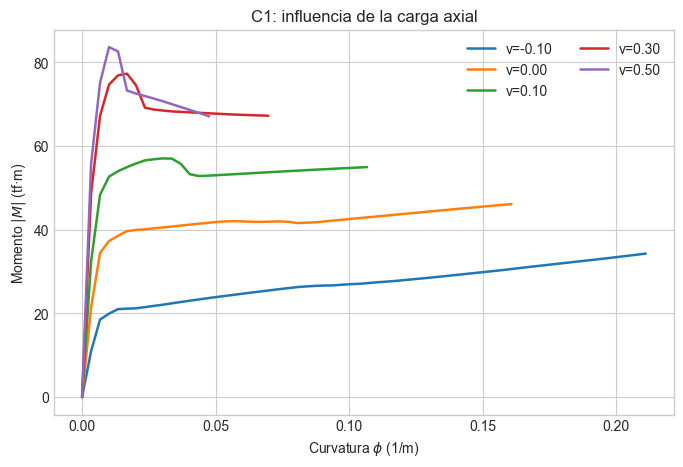

     ν     P (tf)    My (tf·m)    Mu (tf·m)     φy (1/m)     evento
 -0.10     -75.60       18.543       34.300      0.00672      acero
  0.00       0.00       34.501       46.143      0.00672   concreto
  0.10      75.60       48.390       57.064      0.00672   concreto
  0.30     226.80       74.712       77.318      0.01008   concreto
  0.50     378.00       75.136       83.680      0.00672   concreto


In [8]:
niveles_nu = [-0.10, 0.00, 0.10, 0.30, 0.50]
resumenes_axiales = []
fig, ax = plt.subplots(figsize=(8, 5))

for nu_i in niveles_nu:
    P_i = nu_i * d["Ag"] * d["fco"]
    regs_i = curva_momento_curvatura(
        P_i, fibras, d, cfg_c1["fl_ef"], cfg_c1["rho_s"], cfg_c1["eps_cu"],
        phi_max=entrada["biblioteca_rotulas"]["phi_max_1_cm"],
        n_pasos=entrada["biblioteca_rotulas"]["n_pasos"],
    )
    res_i = resumir_curva(regs_i, P_i)
    res_i["nu"] = nu_i
    resumenes_axiales.append(res_i)
    ax.plot(np.array([r['phi'] for r in regs_i])*100,
            np.abs([r['M'] for r in regs_i])/1e5, lw=1.8, label=f"ν={nu_i:.2f}")

ax.set(xlabel=r"Curvatura $\phi$ (1/m)", ylabel=r"Momento $|M|$ (tf·m)",
       title="C1: influencia de la carga axial")
ax.legend(ncol=2)
plt.show()

print(f"{'ν':>6} {'P (tf)':>10} {'My (tf·m)':>12} {'Mu (tf·m)':>12} {'φy (1/m)':>12} {'evento':>10}")
for r in resumenes_axiales:
    print(f"{r['nu']:6.2f} {r['P_kgf']/1000:10.2f} {r['My_kgf_cm']/1e5:12.3f} "
          f"{r['Mu_kgf_cm']/1e5:12.3f} {r['phi_y_1_cm']*100:12.5f} {r['evento_final']:>10}")


## 7. De $M$–$\phi$ a una rótula plástica concentrada

El modelo estructural de las sesiones 5 y 6 concentra la no linealidad en los extremos de vigas y columnas. La respuesta seccional se transforma mediante

$$\theta_{L_p}=\phi L_p,\qquad \theta_p=\max[(\phi-\phi_y)L_p,0].$$

En el JSON del ejemplo se adopta $L_p=0.5h$. Esta es una decisión de modelación documentada, no una longitud universal. Los límites IO–LS–CP no se deducen de la curva de fibras: el sistema portable los incorpora después desde un catálogo externo trazable.

Lp = 30.00 cm
My = 48.390 tf·m
Mu = 57.064 tf·m
θ local de fluencia = 0.002017 rad
θp última calculada = 0.029991 rad
Criterios IO–LS–CP  = pendientes


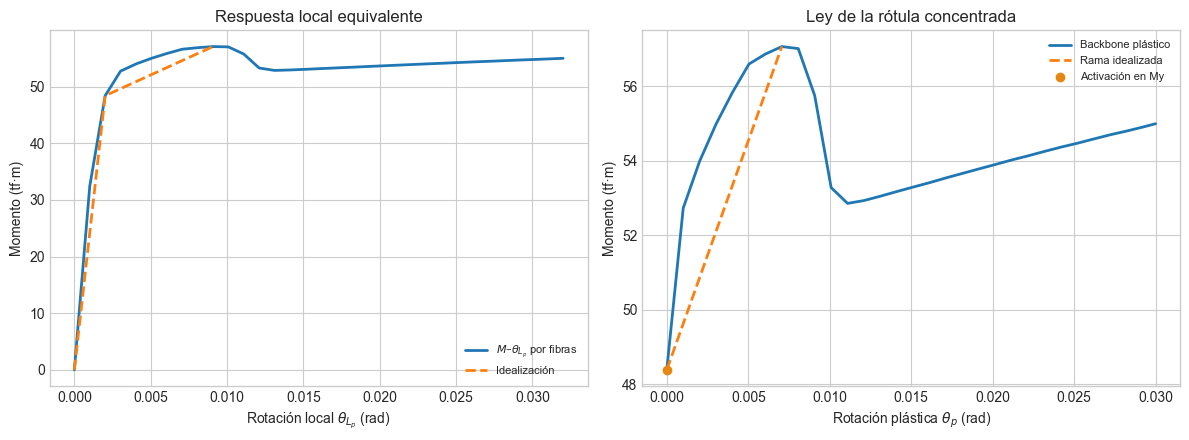

In [9]:
rotula_c1 = propiedades_rotula(
    registros, resumen, d, Lp=cfg_c1["Lp_cm"], criterios=None
)
theta_local = np.array(rotula_c1["respuesta_local"]["theta_rad"])
M_local = np.array(rotula_c1["respuesta_local"]["M_kgf_cm"])
theta_p = np.array(rotula_c1["backbone_plastico"]["theta_p_rad"])
M_p = np.array(rotula_c1["backbone_plastico"]["M_kgf_cm"])
bil = rotula_c1["bilinealizacion"]

print(f"Lp = {rotula_c1['Lp_cm']:.2f} cm")
print(f"My = {rotula_c1['My_kgf_cm']/1e5:.3f} tf·m")
print(f"Mu = {rotula_c1['Mu_kgf_cm']/1e5:.3f} tf·m")
print(f"θ local de fluencia = {rotula_c1['theta_local_y_rad']:.6f} rad")
print(f"θp última calculada = {rotula_c1['theta_p_u_rad']:.6f} rad")
print(f"Criterios IO–LS–CP  = {rotula_c1['criterios_aceptacion']['estado']}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(theta_local, M_local/1e5, lw=2, label=r"$M$–$\theta_{L_p}$ por fibras")
axes[0].plot(np.array(bil['M_theta_local']['theta_rad']),
             np.array(bil['M_theta_local']['M_kgf_cm'])/1e5, '--', lw=2, label="Idealización")
axes[0].set(xlabel=r"Rotación local $\theta_{L_p}$ (rad)", ylabel="Momento (tf·m)",
            title="Respuesta local equivalente")
axes[0].legend(fontsize=8)

axes[1].plot(theta_p, M_p/1e5, lw=2, label="Backbone plástico")
axes[1].plot(np.array(bil['rama_plastica']['theta_p_rad']),
             np.array(bil['rama_plastica']['M_kgf_cm'])/1e5, '--', lw=2, label="Rama idealizada")
axes[1].scatter(0, rotula_c1['My_kgf_cm']/1e5, color="#e68613", zorder=3, label="Activación en My")
axes[1].set(xlabel=r"Rotación plástica $\theta_p$ (rad)", ylabel="Momento (tf·m)",
            title="Ley de la rótula concentrada")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

assert rotula_c1["criterios_aceptacion"]["estado"] == "pendientes"


## 8. Biblioteca completa $M$–$\theta(P)$ del edificio

Ahora se ejecuta el generador oficial de `PUSHOVER_PORTABLE`. Para cada sección se calculan las ramas de momento positivo y negativo en toda la malla axial definida por el JSON:

- columnas: $\nu=-0.10,0.00,0.10,0.20,0.30,0.40,0.50$;
- vigas: $P=-20000,0,+20000$ kgf.

Las ramas positiva y negativa son necesarias porque el refuerzo superior e inferior de las vigas puede ser diferente.

In [10]:
biblioteca, metadata = generar_biblioteca_desde_entrada(RUTA_JSON)

print(f"{'Sección':<9} {'Tipo':<9} {'Rama +':>8} {'Rama -':>8} {'Lp (cm)':>9}")
for sid in sorted(biblioteca):
    fam = biblioteca[sid]
    print(f"{sid:<9} {metadata[sid]['tipo']:<9} {len(fam['positivo']):8d} "
          f"{len(fam['negativo']):8d} {metadata[sid]['Lp_cm']:9.1f}")

assert set(biblioteca) == set(secciones_json)
for sid, fam in biblioteca.items():
    esperado = 7 if metadata[sid]["tipo"] == "columna" else 3
    assert len(fam["positivo"]) == len(fam["negativo"]) == esperado


Sección   Tipo        Rama +   Rama -   Lp (cm)
C1        columna          7        7      30.0
C2        columna          7        7      27.5
V1        viga             3        3      27.5
V2        viga             3        3      20.0


### 8.1 Diagrama de interacción reducido de la biblioteca

La biblioteca no sustituye un diagrama completo $P$–$M$, pero permite visualizar cómo varían $M_y$ y $M_u$ dentro del intervalo axial que usará la calibración gravitacional.

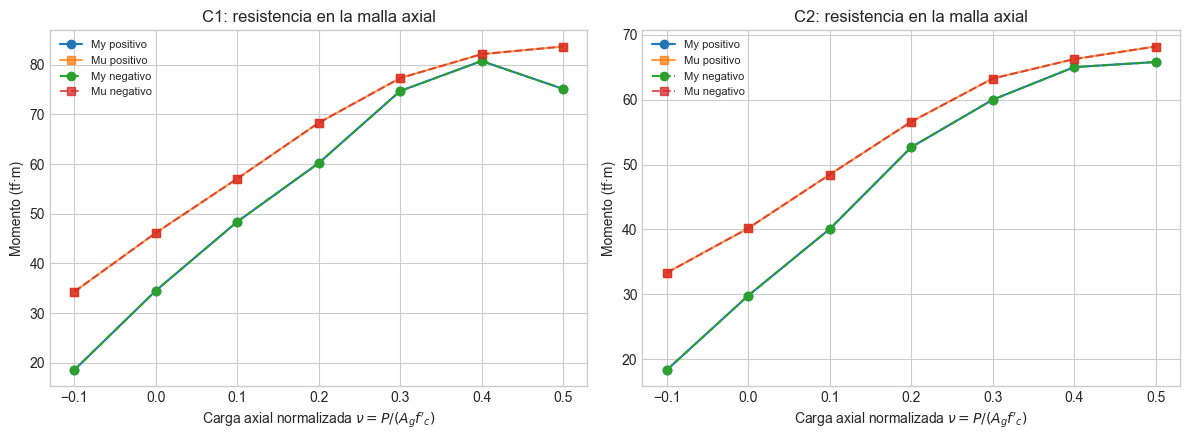

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, sid in zip(axes, ("C1", "C2")):
    meta = metadata[sid]
    Ag_fc = meta["b_cm"] * meta["h_cm"] * meta["fc_kgf_cm2"]
    for sentido, estilo in (("positivo", "-"), ("negativo", "--")):
        filas = biblioteca[sid][sentido]
        nu_vals = np.array([f['P_kgf'] for f in filas]) / Ag_fc
        My_vals = np.array([f['ley']['My_kgf_cm'] for f in filas]) / 1e5
        Mu_vals = np.array([f['ley']['Mu_kgf_cm'] for f in filas]) / 1e5
        ax.plot(nu_vals, My_vals, estilo, marker='o', label=f"My {sentido}")
        ax.plot(nu_vals, Mu_vals, estilo, marker='s', alpha=0.75, label=f"Mu {sentido}")
    ax.set(xlabel=r"Carga axial normalizada $\nu=P/(A_gf'_c)$",
           ylabel="Momento (tf·m)", title=f"{sid}: resistencia en la malla axial")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 9. Exportación del contrato de la sesión 3

El contrato `schema_version = 3.5` conserva unidades, metadatos y todas las leyes reducidas. En sesiones posteriores, la carga axial gravitacional de cada elemento permitirá interpolar dentro de esta biblioteca.

In [12]:
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)
RUTA_CONTRATO = RUTA_SALIDA / "contrato_sesion03_2pisos.json"
guardar_contrato_sesion03(
    biblioteca, RUTA_CONTRATO, schema_version="3.5",
    metadata_adicional={
        "caso_id": "edificio_2pisos",
        "entrada_relativa": str(RUTA_JSON.relative_to(RAIZ_CURSO)),
        "secciones": metadata,
    },
)

contrato = json.loads(RUTA_CONTRATO.read_text(encoding="utf-8"))
print("Contrato guardado:", RUTA_CONTRATO.relative_to(RAIZ_CURSO))
print("Versión de esquema :", contrato["schema_version"])
print("Secciones          :", ", ".join(contrato["secciones"]))
print(f"Tamaño             : {RUTA_CONTRATO.stat().st_size/1024:.1f} KiB")


Contrato guardado: sesion_03\resultados_portable_2pisos\contrato_sesion03_2pisos.json
Versión de esquema : 3.5
Secciones          : C1, C2, V1, V2
Tamaño             : 44.7 KiB


## 10. Verificaciones automáticas

Las comprobaciones siguientes no demuestran por sí solas que el modelo represente una estructura real, pero detectan errores de unidades, áreas, equilibrio, orden de la malla axial y propiedades no físicas.

In [13]:
# Equilibrio axial de todos los estados de la curva didáctica
escala_N = max(abs(P), d["Ag"] * d["fco"])
residuos_N = np.array([abs(r["N"] - P) for r in registros])
assert residuos_N.max() <= 1e-5 * escala_N

# La curva termina en el primer límite material, sin puntos espurios posteriores
usos = [utilizacion_limite(r, d, cfg_c1["eps_cu"])[0] for r in registros]
assert max(usos[:-1]) < 1.0
assert np.isclose(usos[-1], 1.0, atol=1e-8)

# Coherencia de cada familia M-theta(P)
for sid, familia in biblioteca.items():
    for sentido in ("positivo", "negativo"):
        filas = familia[sentido]
        cargas = np.array([f["P_kgf"] for f in filas])
        assert np.all(np.diff(cargas) > 0)
        for fila in filas:
            ley = fila["ley"]
            assert fila["EI_sec_kgf_cm2"] > 0
            assert 0 < ley["My_kgf_cm"] <= ley["Mu_kgf_cm"]
            assert ley["theta_p_u_rad"] >= 0
            assert np.isfinite(ley["Kp_kgf_cm_rad"])

assert contrato["schema_version"] == "3.5"
assert contrato["sesion_origen"] == "sesion_03"
assert set(contrato["biblioteca_rotulas"]) == {"C1", "C2", "V1", "V2"}

print(f"Máximo residuo axial: {residuos_N.max():.4f} kgf")
print("Verificaciones geométricas, mecánicas y de contrato: APROBADAS")


Máximo residuo axial: 7.5500 kgf
Verificaciones geométricas, mecánicas y de contrato: APROBADAS


## 11. Interpretación y cierre

### Hallazgos principales

- La curva $M$–$\phi$ surge de compatibilidad, leyes constitutivas y equilibrio axial; no es una curva impuesta.
- La carga axial cambia la resistencia y la deformabilidad de las columnas, por lo que el sistema construye una familia $M$–$\theta(P)$.
- La rótula concentrada separa la rotación elástica local de la rotación plástica mediante $L_p$.
- La salida computacional de esta sesión es el contrato 3.5, que transfiere propiedades verificables a las sesiones siguientes.

### Supuestos críticos y limitaciones

- Secciones planas permanecen planas y existe adherencia perfecta acero–concreto.
- Se adopta respuesta monotónica; no se modelan ciclos, pinching ni degradación cíclica.
- $L_p=0.5h$ es el criterio adoptado en el JSON del curso y debe justificarse para cada aplicación.
- La curva de fibras representa falla material flexional, pero no verifica modos frágiles por cortante.
- Los límites IO–LS–CP deben venir de un catálogo externo calculado y revisado; no se inventan en esta sesión.

### Siguiente paso

En la **Sesión 4** se utilizarán $EA$, $EI_{sec}$ y las leyes reducidas para estudiar la matriz de rigidez del elemento y los algoritmos iterativos no lineales.

### Ejercicios propuestos

1. Comparar las ramas positiva y negativa de `V1` y explicar el efecto del refuerzo asimétrico.
2. Cambiar solo el espaciamiento de estribos de una copia del JSON y estudiar $f'_{cc}$, $\varepsilon_{cu}$ y $\theta_{p,u}$.
3. Repetir C1 con una discretización de 40, 80 y 160 franjas y cuantificar la convergencia de $M_y$.